# libcmaes vs Minion CMA-ES variants

This notebook compares Minion's `CMAES`, `BIPOP_aCMAES`, and `RCMAES` against libcmaes on the same benchmark plumbing.

The notebook does three things:
- builds libcmaes as a shared library when needed,
- compiles a tiny pybind11 bridge so Python can call libcmaes directly,
- runs the same CEC and BBOB objectives through both stacks and plots the error curves.

In [4]:
from __future__ import annotations

import math
import os
import subprocess
import sys
import sysconfig
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')


def find_repo_root() -> Path:
    current = Path.cwd().resolve()
    while True:
        if (current / 'external' / 'libcmaes').exists() and (current / 'minionpy').exists():
            return current
        if current.parent == current:
            raise RuntimeError('Could not locate the repository root')
        current = current.parent


REPO_ROOT = find_repo_root()
EXAMPLES_DIR = REPO_ROOT / 'examples'
LIBCMAES_ROOT = REPO_ROOT / 'external' / 'libcmaes'
LIBCMAES_BUILD = LIBCMAES_ROOT / 'build'
EIGEN_SRC = REPO_ROOT / 'build' / '_deps' / 'eigen-src'
if not EIGEN_SRC.exists():
    EIGEN_SRC = LIBCMAES_ROOT / '_deps' / 'eigen-src'
if not EIGEN_SRC.exists():
    EIGEN_SRC.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ['git', 'clone', '--depth', '1', 'https://gitlab.com/libeigen/eigen.git', str(EIGEN_SRC)],
        check=True,
    )
EIGEN_BUILD = LIBCMAES_ROOT / 'eigen-build'
BRIDGE_BUILD = EXAMPLES_DIR / '_build'
BRIDGE_BUILD.mkdir(parents=True, exist_ok=True)

EXT_SUFFIX = sysconfig.get_config_var('EXT_SUFFIX') or '.so'
BRIDGE_SO = BRIDGE_BUILD / f'libcmaes_bridge{EXT_SUFFIX}'

if not (EIGEN_BUILD / 'Eigen3Config.cmake').exists():
    subprocess.run(
        [
            'cmake',
            '-S', str(EIGEN_SRC),
            '-B', str(EIGEN_BUILD),
            '-DEIGEN_BUILD_PKGCONFIG=OFF',
            '-DEIGEN_BUILD_TESTING=OFF',
            '-DEIGEN_BUILD_DOC=OFF',
        ],
        check=True,
    )

if not (LIBCMAES_BUILD / 'src' / 'libcmaes.so').exists():
    subprocess.run(
        [
            'cmake',
            '-S', str(LIBCMAES_ROOT),
            '-B', str(LIBCMAES_BUILD),
            '-DLIBCMAES_BUILD_SHARED_LIBS=ON',
            '-DLIBCMAES_BUILD_PYTHON=OFF',
            '-DLIBCMAES_BUILD_TESTS=OFF',
            '-DLIBCMAES_BUILD_EXAMPLES=OFF',
            f'-DEigen3_DIR={EIGEN_BUILD}',
        ],
        check=True,
    )
    subprocess.run(['cmake', '--build', str(LIBCMAES_BUILD), '-j2'], check=True)

BRIDGE_SRC = EXAMPLES_DIR / 'libcmaes_bridge.cpp'
if (not BRIDGE_SO.exists()) or BRIDGE_SO.stat().st_mtime < BRIDGE_SRC.stat().st_mtime:
    pybind_includes = subprocess.check_output(
        [sys.executable, '-m', 'pybind11', '--includes'],
        text=True,
    ).split()
    cxx = os.environ.get('CXX', 'c++')
    libcmaes_sources = sorted(str(p) for p in (LIBCMAES_ROOT / 'src').glob('*.cc'))
    compile_cmd = [
        cxx,
        '-O3',
        '-std=c++17',
        '-shared',
        '-fPIC',
        '-fopenmp',
        *pybind_includes,
        '-I', str(LIBCMAES_ROOT / 'include'),
        '-I', str(LIBCMAES_BUILD / 'include'),
        '-I', str(EIGEN_SRC),
        *libcmaes_sources,
        str(BRIDGE_SRC),
        '-o', str(BRIDGE_SO),
    ]
    subprocess.run(compile_cmd, check=True)

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(BRIDGE_BUILD))

import importlib

import cocoex
import minionpy as mpy
if 'libcmaes_bridge' in sys.modules:
    del sys.modules['libcmaes_bridge']
importlib.invalidate_caches()
libcmaes_bridge = importlib.import_module('libcmaes_bridge')

print('Repository root:', REPO_ROOT)
print('libcmaes bridge:', BRIDGE_SO)
print('libcmaes import:', libcmaes_bridge.__doc__)

Repository root: /home/muzakka/Developments/minion
libcmaes bridge: /home/muzakka/Developments/minion/examples/_build/libcmaes_bridge.cpython-313-x86_64-linux-gnu.so
libcmaes import: Minimal libcmaes bridge for benchmark comparisons


In [5]:
# Benchmark helpers.

def recommended_lambda(dimension: int) -> int:
    return max(5, 4 + int(math.floor(3.0 * math.log(dimension))))


class ProgressTracker:
    def __init__(self, fopt: float, progress_step: int):
        self.fopt = float(fopt)
        self.progress_step = max(1, int(progress_step))
        self.evals = 0
        self.best = math.inf
        self.next_progress = self.progress_step
        self.eval_history: list[int] = []
        self.err_history: list[float] = []

    def _record_progress(self) -> None:
        while self.evals >= self.next_progress:
            self.eval_history.append(self.next_progress)
            self.err_history.append(max(abs(self.best - self.fopt), 1e-300))
            self.next_progress += self.progress_step

    def update(self, values) -> None:
        for value in np.asarray(values, dtype=float).ravel():
            self.evals += 1
            value = float(value)
            if value < self.best:
                self.best = value
            self._record_progress()

    def batch_objective(self, scalar_objective):
        def wrapped(x_batch):
            x_batch = np.asarray(x_batch, dtype=float)
            if x_batch.ndim == 1:
                x_batch = x_batch[None, :]
            values = [float(scalar_objective(x)) for x in x_batch]
            self.update(values)
            return values
        return wrapped

    def scalar_objective(self, scalar_objective):
        def wrapped(x):
            value = float(scalar_objective(np.asarray(x, dtype=float)))
            self.update([value])
            return value
        return wrapped

    @property
    def final_error(self) -> float:
        return max(abs(self.best - self.fopt), 1e-300)


MINION_ALGOS = [
    ('Minion CMAES', 'CMAES', 0.3),
    ('Minion BIPOP_aCMAES', 'BIPOP_aCMAES', 0.3),
    ('Minion RCMAES', 'RCMAES', 0.2),
]

LIBCMAES_ALGOS = [
    ('libcmaes cmaes', 'cmaes', 0.3),
    ('libcmaes acmaes', 'acmaes', 0.3),
    ('libcmaes bipop', 'bipop', 0.3),
    ('libcmaes abipop', 'abipop', 0.3),
]


def make_cec2017_problem(function_number: int, dimension: int):
    cec = mpy.CEC2017Functions(function_number, dimension)
    fopt = 100*function_number
    bounds = [(-100.0, 100.0)] * dimension
    x0 = [0.0] * dimension

    def scalar(x):
        return float(cec([np.asarray(x, dtype=float).tolist()])[0])

    return scalar, fopt, bounds, x0



def make_bbob_problem(function_number: int, dimension: int):
    problem = cocoex.BareProblem(
        suite_name='bbob',
        function=function_number,
        dimension=dimension,
        instance=1,
    )
    fopt = float(problem.best_value())
    bounds = [(-5.0, 5.0)] * dimension
    x0 = [0.0] * dimension

    def scalar(x):
        return float(problem(np.asarray(x, dtype=float)))

    return scalar, fopt, bounds, x0, problem.id



def minion_options(algo_name: str, dimension: int, lambda_: int, sigma0: float):
    common = {
        'population_size': 0,
        'bound_strategy': 'reflect-random',
        'convergence_tol': 0.0,
    }
    return common
    if algo_name == 'CMAES':
        common.update({
            'mu': max(1, lambda_ // 2),
            'cc': 0.0,
            'cs': 0.0,
            'c1': 0.0,
            'cmu': 0.0,
            'damps': 0.0,
        })
    elif algo_name == 'BIPOP_aCMAES':
        common.update({
            'max_iterations': 5000,
        })
    elif algo_name == 'RCMAES':
        pass
    else:
        raise ValueError(f'Unsupported Minion algorithm: {algo_name}')
    return common



def run_minion(algo_label: str, algo_name: str, scalar_objective, bounds, x0, budget: int, seed: int, sigma0: float, progress_step: int, fopt: float):
    tracker = ProgressTracker(fopt, progress_step)
    objective = tracker.batch_objective(scalar_objective)
    dim = len(bounds)
    lambda_ = recommended_lambda(dim)
    options = minion_options(algo_name, dim, lambda_, sigma0)
    result = mpy.Minimizer(
        func=objective,
        bounds=bounds,
        x0=[x0],
        algo=algo_name,
        maxevals=budget,
        seed=seed,
        options=options,
    ).optimize()
    return {
        'family': 'minion',
        'label': algo_label,
        'algorithm': algo_name,
        'best_f': float(result.fun),
        'nfev': int(result.nfev),
        'error': tracker.final_error,
        'tracker': tracker,
        'result': result,
    }



def run_libcmaes(algo_label: str, algo_name: str, scalar_objective, bounds, x0, budget: int, seed: int, sigma0: float, progress_step: int, fopt: float):
    tracker = ProgressTracker(fopt, progress_step)
    dim = len(bounds)
    lambda_ = recommended_lambda(dim)
    objective = tracker.scalar_objective(scalar_objective)
    x0_list = [float(v) for v in np.asarray(x0, dtype=float).ravel().tolist()]
    bounds_list = [(float(lo), float(hi)) for lo, hi in bounds]
    try:
        result = libcmaes_bridge.optimize(
            objective=objective,
            x0=x0_list,
            sigma0=float(sigma0),
            bounds=bounds_list,
            algo=str(algo_name),
            **{'lambda': int(lambda_)},
            seed=int(seed),
            maxevals=int(budget),
        )
        return {
            'family': 'libcmaes',
            'label': algo_label,
            'algorithm': algo_name,
            'best_f': float(result['best_f']),
            'nfev': int(result['nevals']),
            'error': tracker.final_error,
            'tracker': tracker,
            'result': result,
            'status': 'ok',
        }
    except Exception as exc:
        return {
            'family': 'libcmaes',
            'label': algo_label,
            'algorithm': algo_name,
            'best_f': math.inf,
            'nfev': 0,
            'error': tracker.final_error,
            'tracker': tracker,
            'result': None,
            'status': f'failed: {exc}',
        }



def summarize_records(records):
    print(f"{'Label':<24}{'best_f':>16}{'nfev':>12}{'error':>16}  status")
    print('-' * 92)
    for record in records:
        status = record.get('status', 'ok')
        print(f"{record['label']:<24}{record['best_f']:>16.8e}{record['nfev']:>12}{record['error']:>16.8e}  {status}")



def plot_records(records, title: str, dimension: int):
    plt.figure(figsize=(10, 6))
    for record in records:
        tracker = record['tracker']
        if not tracker.eval_history:
            continue
        xvals = np.asarray(tracker.eval_history, dtype=float) / float(dimension)
        yvals = np.asarray(tracker.err_history, dtype=float)
        plt.semilogy(xvals, yvals, label=record['label'])
    plt.xlabel(r'$\#\mathrm{evals} / D$')
    plt.ylabel(r'$|f - f_{opt}|$')
    plt.title(title)
    plt.grid(True, which='both', alpha=0.3)
    plt.legend()
    plt.tight_layout()

CEC2017 functions: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 15, 25, 29]
CEC2017 F1
Label                             best_f        nfev           error  status
--------------------------------------------------------------------------------------------
Minion CMAES              1.00000000e+02        8080 1.00000000e-300  ok
Minion BIPOP_aCMAES       1.00000000e+02        6000 1.00000000e-300  ok
Minion RCMAES             1.00000000e+02        8248  2.19873996e-07  ok
libcmaes cmaes            1.00000000e+02        6220 1.00000000e-300  ok
libcmaes acmaes           1.00000000e+02        5530 1.00000000e-300  ok
libcmaes bipop            1.00000000e+02        6220 1.00000000e-300  ok
libcmaes abipop           1.00000000e+02        5530 1.00000000e-300  ok
CEC2017 F2
Label                             best_f        nfev           error  status
--------------------------------------------------------------------------------------------
Minion CMAES              2.00000067e+02        9930  6.7415

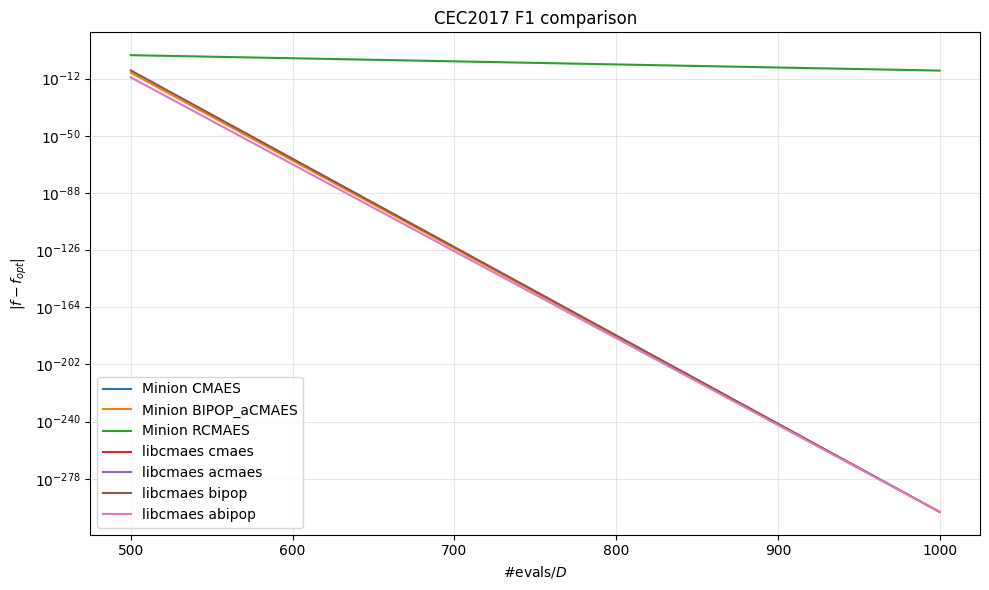

In [6]:
# CEC 2017 comparison.

CEC_DIMENSION = 10
CEC_BUDGET = 10_000
CEC_SEED = 20250306
CEC_PROGRESS_STEP = 5000
RUN_FULL_CEC = False
CEC_FUNCTIONS = list(range(1, 31)) if RUN_FULL_CEC else [1, 2, 3, 4, 5, 6,7,8,9,10, 11, 15, 25, 29]

cec_records = []
for function_number in CEC_FUNCTIONS:
    scalar, fopt, bounds, x0 = make_cec2017_problem(function_number, CEC_DIMENSION)
    for label, algo_name, sigma0 in MINION_ALGOS:
        cec_records.append(
            {
                **run_minion(label, algo_name, scalar, bounds, x0, CEC_BUDGET, CEC_SEED, sigma0, CEC_PROGRESS_STEP, fopt),
                'function_number': function_number,
                'problem': f'CEC2017 F{function_number}',
            }
        )
    for label, algo_name, sigma0 in LIBCMAES_ALGOS:
        cec_records.append(
            {
                **run_libcmaes(label, algo_name, scalar, bounds, x0, CEC_BUDGET, CEC_SEED, sigma0, CEC_PROGRESS_STEP, fopt),
                'function_number': function_number,
                'problem': f'CEC2017 F{function_number}',
            }
        )

print(f'CEC2017 functions: {CEC_FUNCTIONS}')
for function_number in CEC_FUNCTIONS:
    print(f'CEC2017 F{function_number}')
    summarize_records([r for r in cec_records if r['function_number'] == function_number])

selected_cec = 18 if 18 in CEC_FUNCTIONS else CEC_FUNCTIONS[0]
plot_records([r for r in cec_records if r['function_number'] == selected_cec], f'CEC2017 F{selected_cec} comparison', CEC_DIMENSION)

BBOB problem: bbob_f007_i01_d10
Label                             best_f        nfev           error  status
--------------------------------------------------------------------------------------------
Minion CMAES              9.41042311e+01         580  1.16423112e+00  ok
Minion BIPOP_aCMAES       9.29400000e+01       92480 1.00000000e-300  ok
Minion RCMAES             9.29400000e+01       29792  2.03215222e-12  ok
libcmaes cmaes            9.96114510e+01        1470  6.67145103e+00  ok
libcmaes acmaes           9.59909226e+01        1460  3.00175659e+00  ok
libcmaes bipop            9.29400000e+01        9600 1.00000000e-300  ok
libcmaes abipop                      inf           0 1.00000000e-300  failed: cannot create std::vector larger than max_size()


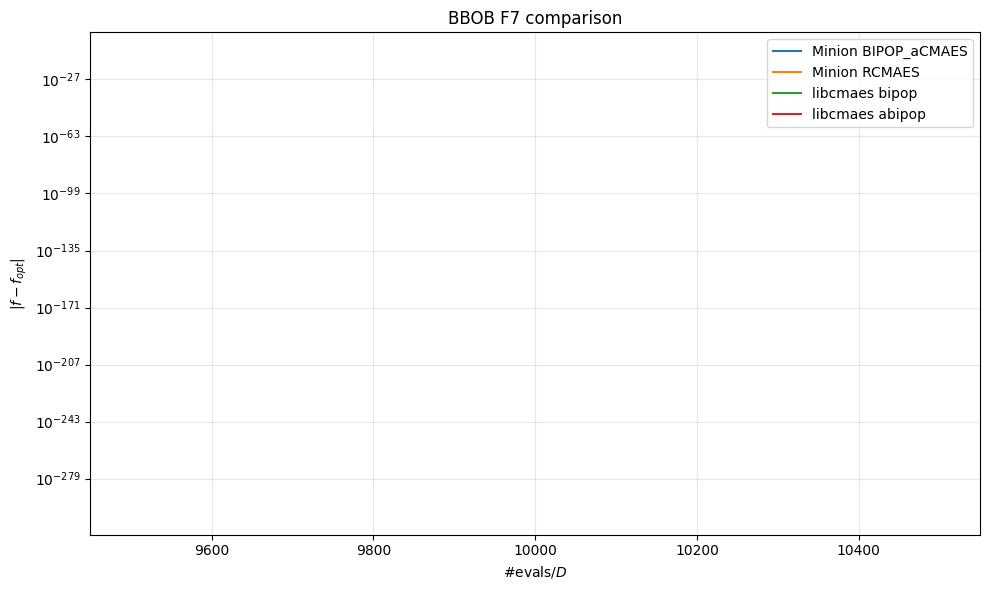

In [7]:
# BBOB comparison for the same setup as examples/test.py.

BBOB_FUNCTION = 7
BBOB_DIMENSION = 10
BBOB_BUDGET = 1_00_000
BBOB_SEED = 20250306
BBOB_PROGRESS_STEP = 100_000

scalar, fopt, bounds, x0, bbob_problem_id = make_bbob_problem(BBOB_FUNCTION, BBOB_DIMENSION)
bbob_records = []
for label, algo_name, sigma0 in MINION_ALGOS:
    bbob_records.append(run_minion(label, algo_name, scalar, bounds, x0, BBOB_BUDGET, BBOB_SEED, sigma0, BBOB_PROGRESS_STEP, fopt))
for label, algo_name, sigma0 in LIBCMAES_ALGOS:
    bbob_records.append(run_libcmaes(label, algo_name, scalar, bounds, x0, BBOB_BUDGET, BBOB_SEED, sigma0, BBOB_PROGRESS_STEP, fopt))

print('BBOB problem:', bbob_problem_id)
summarize_records(bbob_records)
plot_records(bbob_records, f'BBOB F{BBOB_FUNCTION} comparison', BBOB_DIMENSION)

## Notes

- `Minion CMAES` is the plain covariance-update variant.
- `Minion BIPOP_aCMAES` is the active BIPOP restart variant.
- `Minion RCMAES` is Minion's restarting rank-based CMA-ES variant.
- On the libcmaes side the notebook compares `cmaes`, `acmaes`, `bipop`, and `abipop` using the same objectives and budgets.

If you want a quicker pass, keep `RUN_FULL_CEC = False`. Set it to `True` for the full CEC2017 sweep.